# Unsupervised Learning Fundamentals

## Learning Objectives
- Understand the basics and goals of unsupervised learning.
- Learn about clustering and dimensionality reduction concepts.

## Introduction
Unsupervised learning finds hidden patterns or structure in unlabeled data, helping to understand data distribution and discover meaningful groups.

## Core Concepts
- **Clustering:** Grouping similar data points.
- **Dimensionality Reduction:** Reducing feature space while preserving information.
- **Applications:** Customer segmentation, anomaly detection, data visualization.

### Clustering
Clustering is an unsupervised learning method that divides the population or data points into a number of groups or clusters such that data points in the same groups are more similar to other data points in the same group and dissimilar to the data points in other groups.

It can also be described as a grouping of data on the basis of similarity and dissimilarity between them.

### Dimensionality Reduction

This approach seeks to reduce the number of dimensions to the bearest minimum, two or a few, for better outputs. Generally in real life, the fewer the number of parameters in one's decission the easier and better the quality of decisions.

Some of the most popular techniques for achieving this includes PCA (Principal Component Analysis), LDA (Linear Discriminant Analysis), and t-SNE (t-distributed Stochastic Neighbor Embedding).

## Example
Overview of clustering and PCA.

Cluster labels for first 10 samples: [2 2 2 2 0 0 0 0 1 1]


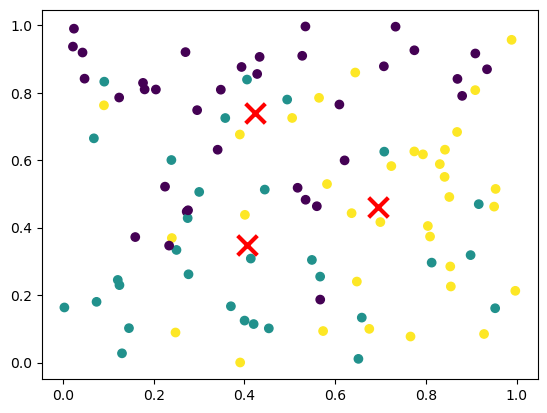

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Generate synthetic data
X = np.random.rand(100, 5)

# PCA to reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

print(f"Cluster labels for first 10 samples: {clusters[:10]}")

# Plot the data and cluster centers
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='x', s=200, linewidths=3, color='r')
plt.show()

### Linear Discriminant Analysis (LDA)

This technique seeks to find a linear combination of features that best separates two or more classes. Unlike PCA, which maximizes variance, LDA aims to maximize the separation between different classes

Training set shape: (105, 4), Testing set shape: (45, 4)


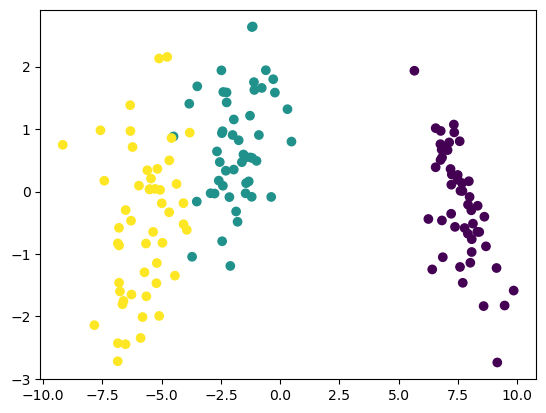

Accuracy: 1.00
Predicted class for new sample: 0


In [6]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set shape: {X_train.shape}, Testing set shape: {X_test.shape}")

# Create and train the Linear Discriminant Analysis model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Visualize the classifier results
transformed = lda.fit_transform(X, y)
xs = transformed[:, 0]
ys = transformed[:, 1]
plt.scatter(xs, ys, c=y)
plt.show()

# Make predictions on the test set
y_pred = lda.predict(X_test)

# Calculate and return the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Do inference on a new sample
new_sample = np.array([[5.1, 3.5, 1.4, 0.2]])  # Example from Iris dataset
print(f"Predicted class for new sample: {lda.predict(new_sample)[0]}")

Customer segmentation example

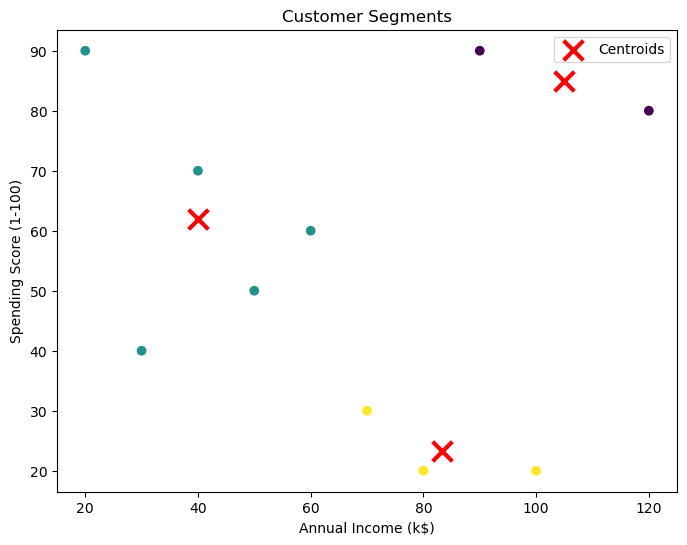

Segment 0: 2 customers
Segment 1: 5 customers
Segment 2: 3 customers


In [7]:
# Generate sample customer data
customer_data = np.array([
    [100, 20],  # [annual_income (k$), spending_score (1-100)]
    [20, 90],
    [60, 60],
    [120, 80],
    [30, 40],
    [80, 20],
    [40, 70],
    [90, 90],
    [70, 30],
    [50, 50]
])

# Apply KMeans clustering
customer_kmeans = KMeans(n_clusters=3, random_state=42)
customer_segments = customer_kmeans.fit_predict(customer_data)

# Visualize the segments
plt.figure(figsize=(8, 6))
plt.scatter(customer_data[:, 0], customer_data[:, 1], c=customer_segments, cmap='viridis')
plt.scatter(customer_kmeans.cluster_centers_[:, 0], customer_kmeans.cluster_centers_[:, 1], 
            marker='x', s=200, linewidths=3, color='r', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.legend()
plt.show()

# Print segment information
for segment in range(3):
    segment_size = (customer_segments == segment).sum()
    print(f"Segment {segment}: {segment_size} customers")

## Exercise
Visualize the PCA-reduced data colored by cluster labels using matplotlib scatter plot.

In [ ]:
# Your code here

## Summary
- Unsupervised learning explores data without labels.
- Clustering and dimensionality reduction are key techniques.


## Further Reading
- [Unsupervised Learning - Wikipedia](https://en.wikipedia.org/wiki/Unsupervised_learning)
- [scikit-learn Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [PCA Tutorial](https://towardsdatascience.com/principal-component-analysis-for-dummies-3bf6b06b5b60)
